In [1]:
!pip install spectral tqdm scikit-learn

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 9.6 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
import os
import numpy as np
import tensorflow as tf
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import spectral

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score

from tensorflow.keras.layers import (
    Input, Conv3D, Conv2D, Dense, Dropout, Reshape,
    Concatenate, Add, Multiply,
    GlobalAveragePooling2D,
    Permute
)

from tensorflow.keras.models import Model

In [3]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Policy:", mixed_precision.global_policy())

Policy: <DTypePolicy "mixed_float16">


In [4]:
def loadData(name):

    data_path = '/content/drive/MyDrive/datasets'

    if name == 'Tangdaowan':
        data = loadmat(os.path.join(data_path, 'QUH-Tangdaowan.mat'))['Tangdaowan']
        labels = loadmat(os.path.join(data_path, 'QUH-Tangdaowan_GT.mat'))['TangdaowanGT']
        class_name = [
            "Rubber track","Flaggingv","Sandy","Asphalt","Boardwalk",
            "Rocky shallows","Grassland","Bulrush","Gravel road",
            "Ligustrum vicaryi","Coniferous pine","Spiraea","Bare soil",
            "Buxus sinica","Photinia serrulata","Populus",
            "Ulmus pumila L","Seawater"
        ]

    elif name == 'Qingyun':
        data = loadmat(os.path.join(data_path, 'QUH-Qingyun.mat'))['Chengqu']
        labels = loadmat(os.path.join(data_path, 'QUH-Qingyun_GT.mat'))['ChengquGT']
        class_name = [
            "Trees","Concrete building","Car",
            "Ironhide building","Plastic playground","Asphalt road"
        ]

    elif name == 'Pingan':
        data = loadmat(os.path.join(data_path, 'QUH-Pingan.mat'))['Haigang']
        labels = loadmat(os.path.join(data_path, 'QUH-Pingan_GT.mat'))['HaigangGT']
        class_name = [
            "Ship","Seawater","Trees","Concrete structure building",
            "Floating pier","Asphalt road","Brick houses",
            "Steel houses","Wharf construction land","Car","Road"
        ]

    return data, labels, class_name

In [5]:
def applyPCA(X, numComponents=15):

    newX = np.reshape(X, (-1, X.shape[2]))

    pca = PCA(n_components=numComponents)

    newX = pca.fit_transform(newX)

    newX = minmax_scale(newX, axis=1)

    newX = np.reshape(newX,(X.shape[0],X.shape[1],numComponents))

    return newX

In [6]:
def get_img_indexes(class_map, removeZeroindexes=True):

    if removeZeroindexes:
        indices = np.argwhere(class_map != 0)
    else:
        indices = np.argwhere(class_map != None)

    labels = class_map[indices[:,0], indices[:,1]]

    indices = [tuple(i) for i in indices]

    return indices, np.array(labels.tolist()) - 1

In [7]:
def splitTrainTestSet(X, y, testRatio):

    return train_test_split(
        X,
        y,
        test_size=testRatio,
        stratify=y,
        random_state=42
    )

In [8]:
def createImageCubes(X, indices, windowSize):

    margin = windowSize // 2

    N,M,P = X.shape

    X_padded = np.zeros((N+2*margin, M+2*margin, P))

    X_padded[margin:N+margin, margin:M+margin,:] = X

    patches=[]

    for idx in indices:

        i,j = idx

        i+=margin
        j+=margin

        patch = X_padded[i-margin:i+margin+1, j-margin:j+margin+1,:]

        patches.append(patch)

    patches=np.array(patches)

    patches = patches[...,np.newaxis]

    return patches

In [9]:
def spectral_mixer_block(x, hidden_dim, num_blocks=2):

    H,W,C,D = x.shape[1:]

    x = Permute((1,2,4,3))(x)

    x = Reshape((H*W, D, C))(x)

    for _ in range(num_blocks):

        x1 = Dense(hidden_dim, activation='gelu')(x)

        x1 = Dense(C)(x1)

        x = Add()([x,x1])

    return Reshape((H,W,C,D))(x)

In [10]:
def spatial_mixer_block(x, hidden_dim, num_blocks=2):

    H,W,C,D = x.shape[1:]

    x = Permute((3,4,1,2))(x)

    x = Reshape((C,D,H*W))(x)

    for _ in range(num_blocks):

        x1 = Dense(hidden_dim, activation='gelu')(x)

        x1 = Dense(H*W)(x1)

        x = Add()([x,x1])

    x = Permute((3,1,2))(x)

    return Reshape((H,W,C,D))(x)

In [18]:
from tensorflow.keras.layers import Lambda, Concatenate, Conv2D, Multiply

def coordinate_attention(x, reduction=32):

    H = x.shape[1]
    W = x.shape[2]
    C = x.shape[3]

    # Height pooling
    pool_h = Lambda(lambda z: tf.reduce_mean(z, axis=2, keepdims=True))(x)

    # Width pooling
    pool_w = Lambda(lambda z: tf.reduce_mean(z, axis=1, keepdims=True))(x)
    pool_w = Lambda(lambda z: tf.transpose(z, perm=[0,2,1,3]))(pool_w)

    y = Concatenate(axis=1)([pool_h, pool_w])

    mid_channels = max(8, C // reduction)

    y = Conv2D(mid_channels, 1, activation='gelu', padding='same')(y)

    # Split features
    x_h = Lambda(lambda z: z[:, :H, :, :])(y)
    x_w = Lambda(lambda z: z[:, H:, :, :])(y)

    x_w = Lambda(lambda z: tf.transpose(z, perm=[0,2,1,3]))(x_w)

    a_h = Conv2D(C, 1, activation='sigmoid', padding='same')(x_h)
    a_w = Conv2D(C, 1, activation='sigmoid', padding='same')(x_w)

    out = Multiply()([x, a_h])
    out = Multiply()([out, a_w])

    return out

In [12]:
def SS_MixNet(img_list, num_classes, mixer_dim=256):

    input_shape = img_list.shape[1:]

    inp = Input(shape=input_shape)

    x = Conv3D(32,(3,3,3),padding='same',activation='gelu')(inp)
    x = Conv3D(64,(3,3,3),padding='same',activation='gelu')(x)

    x_spe = spectral_mixer_block(x, mixer_dim)
    x_spa = spatial_mixer_block(x, mixer_dim)

    x = Concatenate(axis=4)([x_spe,x_spa])

    H,W,C,F = x.shape[1:]

    x = Reshape((H,W,C*F))(x)

    x = coordinate_attention(x)

    res = Conv2D(x.shape[-1],1,padding='same',activation='gelu')(x)

    x = Add()([x,res])

    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.4)(x)

    out = Dense(num_classes,activation='softmax',dtype='float32')(x)

    model = Model(inp,out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    return model

In [13]:
DATASET='Tangdaowan'

data, gt, class_name = loadData(DATASET)

print(data.shape)

(1740, 860, 176)


In [14]:
data = applyPCA(data, numComponents=15)

In [15]:
indexes, labels = get_img_indexes(gt)

X_train_idx, X_test_idx, y_train, y_test = splitTrainTestSet(indexes,labels,0.95)

X_train_idx, X_val_idx, y_train, y_val = splitTrainTestSet(X_train_idx,y_train,0.30)

In [16]:
window_size=9

X_train = createImageCubes(data,X_train_idx,window_size)
X_val = createImageCubes(data,X_val_idx,window_size)

y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)

In [19]:
model = SS_MixNet(
    X_train,
    num_classes=len(class_name),
    mixer_dim=256
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 9, 9, 15,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 9, 9, 15,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 9, 9, 15,  │     55,360 │ conv3d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_4 (Permute) │ (None, 15, 64, 9, │          0 │ conv3d_3[0][0]    │
│                     │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_3 (Permute) │ (None, 9, 9, 64,  │          0 │ conv3d_3[0][0]    │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 15, 64,    │          0 │ permute_4[0][0]   │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 81, 64,    │          0 │ permute_3[0][0]   │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 15, 64,    │     20,992 │ reshape_7[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 81, 64,    │      4,096 │ reshape_5[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 15, 64,    │     20,817 │ dense_12[0][0]    │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 81, 64,    │      3,855 │ dense_8[0][0]     │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 15, 64,    │          0 │ reshape_7[0][0],  │
│                     │ 81)               │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 81, 64,    │          0 │ reshape_5[0][0],  │
│                     │ 15)               │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 15, 64,    │     20,992 │ add_6[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 81, 64,    │      4,096 │ add_4[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 15, 64,    │     20,817 │ dense_14[0][0]    │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 81, 64,    │      3,855 │ dense_10[0][0]  

 Total params: 4,228,174 (16.13 MB)

 Trainable params: 4,228,174 (16.13 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{DATASET}_SS_MixNet_CA.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=8,
    min_lr=5e-5
)

history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=256,
    validation_data=(X_val,y_val),
    callbacks=[checkpoint, lr_callback]
)

Epoch 1/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.3666 - loss: 2.2526
Epoch 1: val_accuracy improved from -inf to 0.64442, saving model to Tangdaowan_SS_MixNet_CA.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 125s 970ms/step - accuracy: 0.3682 - loss: 2.2472 - val_accuracy: 0.6444 - val_loss: 1.2749 - learning_rate: 3.0000e-04
Epoch 2/60
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7020 - loss: 1.1793
Epoch 2: val_accuracy improved from 0.64442 to 0.80421, saving model to Tangdaowan_SS_MixNet_CA.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 263ms/step - accuracy: 0.7030 - loss: 1.1761 - val_accuracy: 0.8042 - val_loss: 0.8878 - learning_rate: 3.0000e-04
Epoch 3/60
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7968 - loss: 0.8804
Epoch 3: val_accuracy improved from 0.80421 to 0.82299, saving model to Tangdaowan_SS_MixNet_CA.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - accuracy: 0.7971 - loss: 0.8796 - val_accuracy: 0.8230 - val_loss: 0.8038 - learning_rate: 3.0000e-04


In [21]:
def predict_by_batching(model, idx, batch_size, X, windowSize):

    preds=[]

    for i in tqdm(range(0,len(idx),batch_size)):

        batch = createImageCubes(X,idx[i:i+batch_size],windowSize)

        preds.append(model.predict(batch,verbose=0))

    return np.concatenate(preds)

In [22]:
Y_pred_test = predict_by_batching(model,X_test_idx,2000,data,window_size)

y_pred_test = np.argmax(Y_pred_test,axis=1)

oa = accuracy_score(y_test,y_pred_test)
kappa = cohen_kappa_score(y_test,y_pred_test)

cm = confusion_matrix(y_test,y_pred_test)

class_acc = cm.diagonal()/cm.sum(axis=1)
aa = np.mean(class_acc)

print("Overall Accuracy:",round(oa*100,2))
print("Average Accuracy:",round(aa*100,2))
print("Kappa:",round(kappa*100,2))

100%|██████████| 265/265 [04:14<00:00,  1.04it/s]

Overall Accuracy: 98.66
Average Accuracy: 97.47
Kappa: 98.47


In [23]:
import pandas as pd
import numpy as np

# -----------------------------
# Compute per-class accuracy
# -----------------------------
class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

rows = []

for i in range(len(class_name)):

    train_count = (y_train.argmax(axis=1) == i).sum()
    val_count   = (y_val.argmax(axis=1) == i).sum()
    test_count  = (y_test == i).sum()
    total_count = (gt == (i+1)).sum()

    rows.append([
        class_name[i],
        train_count,
        val_count,
        test_count,
        total_count,
        round(class_accuracy[i], 2)
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "Train",
        "Val",
        "Test",
        "Total",
        "SS-MixNet (%)"
    ]
)

# -----------------------------
# Summary Metrics
# -----------------------------
summary_rows = pd.DataFrame([
    ["OA (%)", "", "", "", "", round(oa * 100, 2)],
    ["AA (%)", "", "", "", "", round(aa * 100, 2)],
    ["Kappa (×100)", "", "", "", "", round(kappa * 100, 2)]
], columns=df.columns)

df_final = pd.concat([df, summary_rows], ignore_index=True)

# -----------------------------
# Pretty Print Table
# -----------------------------
print("\n")
print("=" * 90)
print(f"{'Classification Performance of SS-MixNet on ' + DATASET:^90}")
print("=" * 90)

print(f"{'Class':<25}{'Train':>8}{'Val':>8}{'Test':>10}{'Total':>10}{'Accuracy (%)':>15}")
print("-" * 90)

for i in range(len(class_name)):
    print(f"{df.iloc[i,0]:<25}"
          f"{df.iloc[i,1]:>8}"
          f"{df.iloc[i,2]:>8}"
          f"{df.iloc[i,3]:>10}"
          f"{df.iloc[i,4]:>10}"
          f"{df.iloc[i,5]:>15}")

print("-" * 90)

print(f"{'Overall Accuracy (OA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(oa*100,2):>15}")
print(f"{'Average Accuracy (AA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(aa*100,2):>15}")
print(f"{'Kappa (×100)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(kappa*100,2):>15}")

print("=" * 90)




                  Classification Performance of SS-MixNet on Tangdaowan                   
Class                       Train     Val      Test     Total   Accuracy (%)
------------------------------------------------------------------------------------------
Rubber track                  904     388     24557     25849          99.92
Flaggingv                    1945     833     52775     55553          99.71
Sandy                        1191     511     32335     34037          98.76
Asphalt                      2124     911     57655     60690          99.76
Boardwalk                      65      28      1769      1862           97.4
Rocky shallows               1299     557     35269     37125          97.87
Grassland                     494     212     13421     14127          91.27
Bulrush                      2243     961     60883     64087          99.95
Gravel road                  1075     460     29160     30695          99.64
Ligustrum vicaryi              62      27     

In [24]:
def get_class_map(model, X, label, window_size):

    indexes = np.argwhere(label != None)

    indexes = [tuple(i) for i in indexes]

    preds = []

    for i in tqdm(range(0, len(indexes), 2000)):
        batch_idx = indexes[i:i+2000]

        patches = createImageCubes(X, batch_idx, window_size)

        y_pred = model.predict(patches, verbose=0)

        preds.append(y_pred)

    preds = np.concatenate(preds)

    preds = np.argmax(preds, axis=1)

    Predicted_Class_Map = np.reshape(preds, label.shape)

    return Predicted_Class_Map

In [25]:
def img_display(data=None, rgb_band=None, classes=None, title=None, figsize=(7,7)):

    if data is not None:
        im_rgb = data[:,:,rgb_band]
        im_rgb = im_rgb / np.max(im_rgb) * 255
        im_rgb = np.asarray(im_rgb, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(im_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

    elif classes is not None:

        unique_classes = np.unique(classes)

        rgb_class = np.zeros((classes.shape[0], classes.shape[1], 3))

        colors = spectral.spy_colors

        for i in unique_classes:
            rgb_class[classes == i] = colors[i]

        rgb_class = np.asarray(rgb_class, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(rgb_class)
        plt.title(title)
        plt.axis('off')
        plt.show()

100%|██████████| 749/749 [11:03<00:00,  1.13it/s]


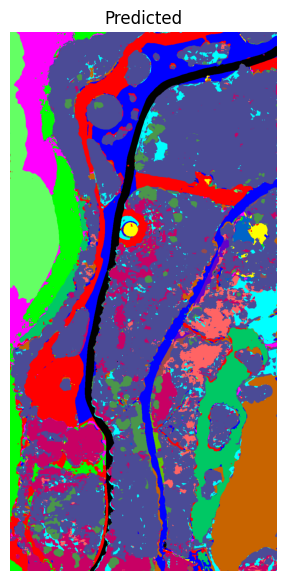

In [26]:
model.load_weights(f"{DATASET}_SS_MixNet_CA.keras")

Predicted_Class_Map = get_class_map(model, data, gt, window_size)

img_display(classes=Predicted_Class_Map, title='Predicted')

In [27]:
model.save("SS_MixNet_CA.keras")

from google.colab import files
files.download("SS_MixNet_CA.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
model.save_weights("SS_MixNet_CA_T4.weights.h5")

from google.colab import files
files.download("SS_MixNet_CA_T4.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import numpy as np

np.save("X_test_idx.npy", X_test_idx)
np.save("y_test.npy", y_test)

from google.colab import files
files.download("X_test_idx.npy")
files.download("y_test.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>